In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

hanhngo120204_ink_data_wird_path = kagglehub.dataset_download('hanhngo120204/ink-data-wird')
hanhngo120204_label_with_pngaaa_path = kagglehub.dataset_download('hanhngo120204/label-with-pngaaa')
hanhngo120204_bestststs_other_default_1_path = kagglehub.model_download('hanhngo120204/bestststs/Other/default/1')

print('Data source import complete.')


Đã chuyển đổi thành công 168 mục và lưu vào: train_labels.json


In [ ]:
!pip install python-doctr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.2/377.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 61.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 79.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.8 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=e74a43cd61ce30598f438c10009b2fa8cd1b818a9b3f801b906d671a50843b09
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
# pip show python-doctr


In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from doctr.models import crnn_mobilenet_v3_large, recognition_predictor
from doctr.datasets import RecognitionDataset
# Sửa lại đường dẫn import ở đây
# from doctr.transforms.modules import Compose
# from doctr.transforms.base import Resize, Normalize, ToTensor
import os
import math
import numpy as np # Để tính toán metrics
from tqdm import tqdm # Để hiển thị thanh tiến trình
from torchvision.transforms import Compose, ToTensor, Normalize, Resize


/usr/local/lib/python3.11/dist-packages/doctr/file_utils.py:86: DeprecationWarning: Support for TensorFlow in DocTR is deprecated and will be removed in the next major release (v1.0.0). Please switch to the PyTorch backend.
  warnings.warn(
2025-06-27 18:18:22.834942: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751048303.030608      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751048303.085719      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
TRAIN_IMG_ROOT_FOLDER = "/kaggle/input/ink-data-wird/InkData_word/InkData_word"
TRAIN_LABEL_FILE = "/kaggle/input/label-with-pngaaa/train_labels_filtered_with_png.json" # File JSON nhãn đã chuyể
OUTPUT_DIR = "/kaggle/working/"
# with open(TRAIN_LABEL_FILE, "r", encoding="utf-8") as f:
#     labels = json.load(f)
# filtered_labels = {}
# missing = []

# for img_name, label in labels.items():
#     img_path = os.path.join(TRAIN_IMG_ROOT_FOLDER, img_name)
#     if os.path.exists(img_path):
#         filtered_labels[img_name] = label
#     else:
#         missing.append(img_name)

# print(f"Số ảnh bị thiếu: {len(missing)}")
# if missing:
#     print("Ví dụ ảnh thiếu:", missing[:5])

# with open(OUTPUT_LABEL_FILE, "w", encoding="utf-8") as f:
#     json.dump(filtered_labels, f, ensure_ascii=False, indent=2)

# print(f"Đã tạo file nhãn mới: {OUTPUT_LABEL_FILE}")

In [ ]:
# import json
# import os

# TRAIN_IMG_ROOT_FOLDER = "/kaggle/input/ink-data-wird/InkData_word/InkData_word"
# TRAIN_LABEL_FILE = "/kaggle/input/word-nabel/train_labels_doctr.json" # File JSON gốc của bạn
# OUTPUT_LABEL_FILE = "/kaggle/working/train_labels_filtered_with_png.json" # File JSON đầu ra đã lọc và thêm .png

# OUTPUT_DIR = "/kaggle/working/"
# os.makedirs(OUTPUT_DIR, exist_ok=True) # Đảm bảo thư mục đầu ra tồn tại

# with open(TRAIN_LABEL_FILE, "r", encoding="utf-8") as f:
#     labels = json.load(f)

# filtered_labels = {}
# missing = []

# # Duyệt qua từng cặp img_name (không có .png) và label trong dictionary
# for img_name_without_ext, label in tqdm (labels.items(), desc='jsd'):
#     # Thêm .png vào tên file để tạo đường dẫn đầy đủ
#     img_name_with_ext = f"{img_name_without_ext}.png"
#     img_path = os.path.join(TRAIN_IMG_ROOT_FOLDER, img_name_with_ext)

#     # Kiểm tra sự tồn tại của file ảnh
#     if os.path.exists(img_path):
#         # Nếu tồn tại, thêm vào filtered_labels với tên file đầy đủ (.png)
#         filtered_labels[img_name_with_ext] = label
#     else:
#         # Nếu không tìm thấy, thêm tên file đầy đủ vào danh sách thiếu
#         missing.append(img_name_with_ext)

# print(f"Số ảnh bị thiếu: {len(missing)}")
# if missing:
#     print("Ví dụ ảnh thiếu (có .png):", missing[:5])

# # Lưu dictionary filtered_labels vào một file JSON mới
# # Đây là file mà bạn sẽ sử dụng cho tham số `labels_path` trong RecognitionDataset
# with open(OUTPUT_LABEL_FILE, "w", encoding="utf-8") as f:
#     json.dump(filtered_labels, f, ensure_ascii=False, indent=2)

# print(f"Đã tạo file nhãn đã lọc và thêm '.png': {OUTPUT_LABEL_FILE}")
# print(f"Số lượng nhãn sau khi lọc: {len(filtered_labels)}")

# # --- Sau khi đoạn mã này chạy xong, bạn sẽ sử dụng OUTPUT_LABEL_FILE cho RecognitionDataset ---
# # Ví dụ:
# # train_dataset = RecognitionDataset(
# #     img_folder=TRAIN_IMG_ROOT_FOLDER,
# #     labels_path=OUTPUT_LABEL_FILE, # SỬ DỤNG FILE JSON MỚI NÀY
# #     charset=reco_model.charset, # Đã điều chỉnh lỗi trước đó
# #     use_cache=True,
# #     training=True
# # )

jsd: 100%|██████████| 110746/110746 [03:41<00:00, 498.86it/s]


Số ảnh bị thiếu: 0
Đã tạo file nhãn đã lọc và thêm '.png': /kaggle/working/train_labels_filtered_with_png.json
Số lượng nhãn sau khi lọc: 110746


In [ ]:
# # Tham số huấn luyện
# BATCH_SIZE = 32
# NUM_EPOCHS = 20 # Số lần lặp qua toàn bộ dataset
# LEARNING_RATE = 1e-4 # Tốc độ học khởi đầu
# MAX_LEARNING_RATE = 1e-3 # Tốc độ học tối đa cho OneCycleLR
# WEIGHT_DECAY = 1e-5
# NUM_WORKERS = 4 # Số luồng để tải dữ liệu (điều chỉnh theo CPU của bạn)

In [ ]:
# Chọn thiết bị (GPU nếu có, CPU nếu không)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Sử dụng thiết bị: {DEVICE}")


Sử dụng thiết bị: cuda


In [ ]:
VOCAB = list("aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬbBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆfFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStTuUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴzZ0123456789!\"#$%&''()*+,-./:;<=>?@[\\]^_`{|}~")


In [ ]:
# # --- 1. Tải và cấu hình mô hình nhận dạng ---
# # Tải mô hình CRNN Mobilenet V3 Large đã được huấn luyện trước
# # Sử dụng vocab tiếng Việt có sẵn của Doctr
# reco_model = crnn_mobilenet_v3_large(pretrained=False, vocab=VOCABS["vietnamese"])

# # Chuyển mô hình lên thiết bị
# reco_model.to(DEVICE)

In [ ]:
# print(f"Model vocab (length): {len(reco_model.charset.char_list)}")
# print(f"Model vocab sample: {reco_model.charset.char_list[:20]}")


In [ ]:
# 3. Khởi tạo model
model = crnn_mobilenet_v3_large(pretrained=False, vocab=VOCAB)
model = model.cuda()
cfg = model.cfg

  0%|          | 0/17658065 [00:00<?, ?it/s]

In [ ]:
img_transforms = Compose([
    Resize(cfg['input_shape'][1:]),  # (32, 128)
    Normalize(mean=cfg['mean'], std=cfg['std']),
])

In [ ]:
train_set = RecognitionDataset(
    img_folder=TRAIN_IMG_ROOT_FOLDER,
    labels_path=TRAIN_LABEL_FILE,
    # use_cache=True,
    # training=True
    img_transforms=img_transforms
)

In [ ]:
from torch.utils.data import random_split, DataLoader



# Chia train/test 80/20
total_len = len(train_set)
train_len = int(0.8 * total_len)
test_len = total_len - train_len
train_subset, test_subset = random_split(train_set, [train_len, test_len])

# Tạo DataLoader
train_loader = DataLoader(train_subset, batch_size=164, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=164, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
imgs, targets = next(iter(train_loader))
print(imgs.shape, type(targets))


torch.Size([164, 3, 32, 128]) <class 'list'>


In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
print(len(VOCAB))

229


In [ ]:
# --- 2. Resume training ---
start_epoch = 25  # mặc định là từ đầu

checkpoint_path = "/kaggle/input/bestststs/other/default/1/best_checkpoint.pth"

In [ ]:
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"✅ Loaded checkpoint from {checkpoint_path}")
else:
    print(f"❌ Checkpoint {checkpoint_path} not found.")
    start_epoch = 0


✅ Loaded checkpoint from /kaggle/input/bestststs/other/default/1/best_checkpoint.pth


In [ ]:
# Cấu hình early stopping
best_val_loss = float("inf")
patience = 5
patience_counter = 0
total_epochs = 60  # Tổng số epoch mong muốn (có thể điều chỉnh)

In [ ]:
from tqdm import tqdm
import torch

for epoch in range(start_epoch, total_epochs):
    model.train()
    train_pbar = tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}")

    total_train_loss = 0.0
    for batch_idx, (imgs, targets) in enumerate(train_pbar):
        try:
            imgs = imgs.cuda()
            out = model(imgs, targets)
            loss = out["loss"]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        except Exception as e:
            print(f"[Train] Error at batch {batch_idx}: {e}")

    avg_train_loss = total_train_loss / len(train_loader)

    # ------------------------
    # Validation step
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in test_loader:
            imgs = imgs.cuda()
            out = model(imgs, targets)
            val_loss = out["loss"]
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    print(f"✅ Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # ------------------------
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, f"best_checkpoint.pth")
        print(f"📦 Saved best model at epoch {epoch+1}")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement in val loss. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

# # ✅ Lưu checkpoint mỗi epoch
#     torch.save({
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#     }, f"checkpoint_epoch_{epoch+1}.pth")
#     print(f"✅ Saved checkpoint for epoch {epoch+1}")


[Train] Epoch 26: 100%|██████████| 541/541 [07:07<00:00,  1.26it/s, loss=0.2116]


✅ Epoch 26 | Train Loss: 0.3157 | Val Loss: 0.3175
📦 Saved best model at epoch 26


[Train] Epoch 27: 100%|██████████| 541/541 [04:26<00:00,  2.03it/s, loss=0.4241]


✅ Epoch 27 | Train Loss: 0.2988 | Val Loss: 0.4265
⚠️ No improvement in val loss. Patience: 1/5


[Train] Epoch 28: 100%|██████████| 541/541 [04:23<00:00,  2.05it/s, loss=0.3962]


...

✅ Epoch 35 | Train Loss: 0.2117 | Val Loss: 0.3372
⚠️ No improvement in val loss. Patience: 3/5


[Train] Epoch 36: 100%|██████████| 541/541 [04:34<00:00,  1.97it/s, loss=0.1887]


✅ Epoch 36 | Train Loss: 0.2036 | Val Loss: 0.4548
⚠️ No improvement in val loss. Patience: 4/5


[Train] Epoch 37: 100%|██████████| 541/541 [04:31<00:00,  1.99it/s, loss=0.1345]


✅ Epoch 37 | Train Loss: 0.1944 | Val Loss: 0.3695
⚠️ No improvement in val loss. Patience: 5/5
⛔ Early stopping triggered.


In [ ]:
import gc
import torch

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Gọi hàm này sau mỗi epoch hoặc khi cần giải phóng RAM
free_memory()

In [ ]:
import torch

ckpt = torch.load("/kaggle/working/best_checkpoint.pth", map_location="cpu")
print(ckpt.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict'])


In [ ]:
# !pip install gradio

In [ ]:
import gradio as gr
import torch
from PIL import Image
from torchvision import transforms

# ⬇️ Giả sử bạn đã định nghĩa sẵn class model = CRNN(...) đúng như khi train
# Ví dụ:
# model = CRNN(img_height=32, num_classes=..., vocab=...)
model.load_state_dict(torch.load("/kaggle/working/best_checkpoint.pth")["model_state_dict"])
model.eval().cuda()

# Preprocess ảnh đầu vào
transform = transforms.Compose([                # nếu input là grayscale
    transforms.Resize((32, 128)),          # resize theo input model
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

# Hàm inference
def ocr_infer(img_pil):
    try:
        img = transform(img_pil).unsqueeze(0).cuda()
        with torch.no_grad():
            out = model(img)  # Không truyền target => inference
        preds = out["preds"]  # Danh sách (chuỗi, xác suất)
        text, conf = preds[0]
        return f"{text} (conf: {conf:.2f})" if preds else "Không nhận dạng được"
    except Exception as e:
        return f"Lỗi: {str(e)}"

# Gradio UI
demo = gr.Interface(
    fn=ocr_infer,
    inputs=gr.Image(type="pil", label="Tải ảnh OCR"),
    outputs=gr.Textbox(label="Chuỗi nhận dạng"),
    title="OCR Demo với CRNN",
    description="Chọn một ảnh văn bản để nhận diện"
)

demo.launch()


/usr/local/lib/python3.11/dist-packages/uvicorn/protocols/websockets/websockets_impl.py:17: DeprecationWarning: websockets.server.WebSocketServerProtocol is deprecated
  from websockets.server import WebSocketServerProtocol


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://c4bb6bb9f68609f6e7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import numpy as np
from tqdm import tqdm
# Chuyển mô hình sang eval mode và GPU (nếu chưa)
model.eval().cuda()
samples = []
confidences = []


with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc='Đánh giá trên toàn bộ tập test'):
        imgs = imgs.cuda()

        # Inference
        out = model(imgs, return_preds=True)
        preds = out["preds"]  # list of (text, confidence)

        for i, (text, conf) in enumerate(preds):
            samples.append((imgs[i].cpu(), text, conf))
            confidences.append(conf)

# Tính trung bình độ tin cậy
avg_conf = np.mean(confidences)
print(f"✅ Độ tin cậy trung bình trên toàn bộ tập test: {avg_conf:.4f}")


Đánh giá trên toàn bộ tập test: 100%|██████████| 136/136 [01:07<00:00,  2.03it/s]

✅ Độ tin cậy trung bình trên toàn bộ tập test: 0.7558


Tổng số mẫu đã thu thập: 22150


/tmp/ipykernel_35/1745815687.py:31: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


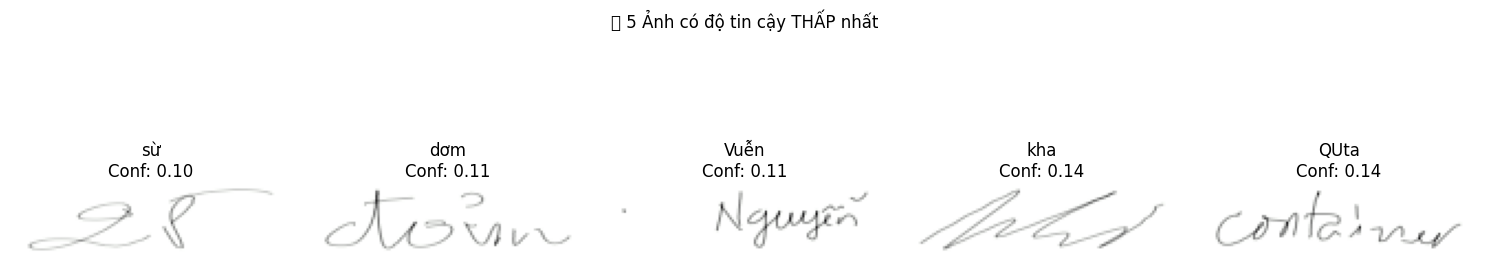

/tmp/ipykernel_35/1745815687.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


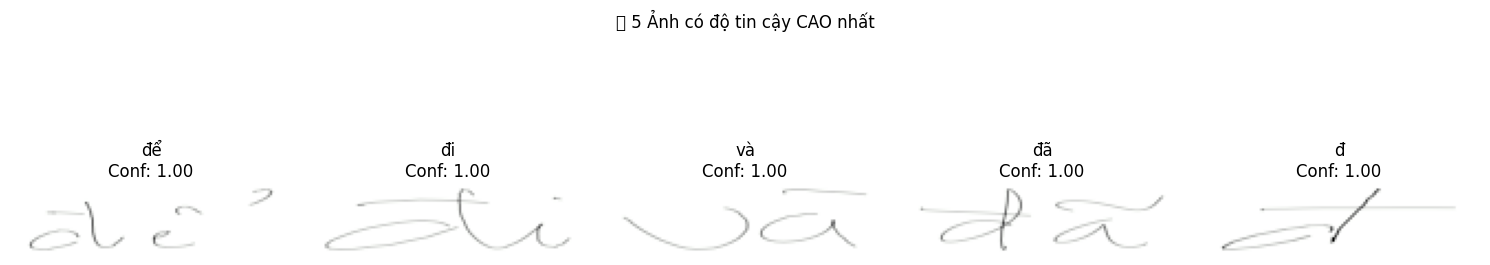

In [ ]:
# Sắp xếp theo confidence
import matplotlib.pyplot as plt
import numpy as np
 # chứa tuple: (image_tensor, predicted_text, confidence)


samples_sorted = sorted(samples, key=lambda x: x[2])  # x[2] là confidence
print(f"Tổng số mẫu đã thu thập: {len(samples_sorted)}")


# Lấy 5 thấp nhất và 5 cao nhất
lowest5 = samples_sorted[:5]
highest5 = samples_sorted[-5:]

def show_images(img_list, title):
    plt.figure(figsize=(15, 4))
    for i, (img, text, conf) in enumerate(img_list):
        plt.subplot(1, 5, i + 1)
        # Nếu ảnh là 3 kênh (C,H,W), chuyển thành (H,W,C)
        img_np = img.numpy()
        if img_np.shape[0] == 1:  # grayscale
            img_np = img_np.squeeze(0)
            plt.imshow(img_np, cmap='gray')
        else:
            img_np = np.transpose(img_np, (1, 2, 0))
            plt.imshow(img_np)

        plt.title(f"{text}\nConf: {conf:.2f}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# 🎯 Hiển thị
show_images(lowest5, "❌ 5 Ảnh có độ tin cậy THẤP nhất")
show_images(highest5, "✅ 5 Ảnh có độ tin cậy CAO nhất")

In [ ]:
# Thêm cell mới vào cuối notebook
# Giả sử biến VOCAB của bạn được định nghĩa ở cell 10
sorted_vocab = sorted(VOCAB)
print("===================================================================")
print("COPY CHUỖI NÀY VÀ PASTE VÀO APP JAVA:")
print(''.join(sorted_vocab))
print("===================================================================")

COPY CHUỖI NÀY VÀ PASTE VÀO APP JAVA:
!"#$%&''()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~ÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝàáâãèéêìíòóôõùúýĂăĐđĨĩŨũƠơƯưẠạẢảẤấẦầẨẩẪẫẬậẮắẰằẲẳẴẵẶặẸẹẺẻẼẽẾếỀềỂểỄễỆệỈỉỊịỌọỎỏỐốỒồỔổỖỗỘộỚớỜờỞởỠỡỢợỤụỦủỨứỪừỬửỮữỰựỲỳỴỵỶỷỸỹ


In [ ]:
# Trong cell notebook của bạn
VOCAB = list("aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬbBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆfFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStTuUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴzZ0123456789!\"#$%&''()*+,-./:;<=>?@[\\]^_`{|}~")
model = crnn_mobilenet_v3_large(pretrained=False, vocab=VOCAB)

# Đây là vocab bạn cung cấp
print("VOCAB GỐC BẠN CUNG CẤP:")
print("".join(VOCAB))
print("-" * 50)
# Đây là vocab mà model thực sự đang sử dụng bên trong
print("VOCAB THỰC TẾ MODEL SỬ DỤNG (model.cfg['vocab']):")
print(model.cfg['vocab'])

VOCAB GỐC BẠN CUNG CẤP:
aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬbBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆfFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStTuUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴzZ0123456789!"#$%&''()*+,-./:;<=>?@[\]^_`{|}~
--------------------------------------------------
VOCAB THỰC TẾ MODEL SỬ DỤNG (model.cfg['vocab']):
['a', 'A', 'à', 'À', 'ả', 'Ả', 'ã', 'Ã', 'á', 'Á', 'ạ', 'Ạ', 'ă', 'Ă', 'ằ', 'Ằ', 'ẳ', 'Ẳ', 'ẵ', 'Ẵ', 'ắ', 'Ắ', 'ặ', 'Ặ', 'â', 'Â', 'ầ', 'Ầ', 'ẩ', 'Ẩ', 'ẫ', 'Ẫ', 'ấ', 'Ấ', 'ậ', 'Ậ', 'b', 'B', 'c', 'C', 'd', 'D', 'đ', 'Đ', 'e', 'E', 'è', 'È', 'ẻ', 'Ẻ', 'ẽ', 'Ẽ', 'é', 'É', 'ẹ', 'Ẹ', 'ê', 'Ê', 'ề', 'Ề', 'ể', 'Ể', 'ễ', 'Ễ', 'ế', 'Ế', 'ệ', 'Ệ', 'f', 'F', 'g', 'G', 'h', 'H', 'i', 'I', 'ì', 'Ì', 'ỉ', 'Ỉ', 'ĩ', 'Ĩ', 'í', 'Í', 'ị', 'Ị', 'j', 'J', 'k', 'K', 'l', 'L', 'm', 'M', 'n', 'N', 'o', 'O', 'ò', 'Ò', 'ỏ', 'Ỏ', 'õ', 'Õ', 'ó', 'Ó', 'ọ', 'Ọ', 'ô', 'Ô', 'ồ', 'Ồ', 'ổ', 'Ổ', 'ỗ', 'Ỗ', 'ố', 'Ố', 'ộ', 'Ộ', 'ơ', 'Ơ', 'ờ', 'Ờ', 'ở', 'Ở', 'ỡ', 'Ỡ', 'ớ',